# Exploratory Data Analysis

Explore cleaned patient, service, and staffing data through summaries, distributions, and charts.

In [1]:
# EXPLORATORY DATA ANALYSIS (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

print("=" * 80)
print("HOSPITAL PATIENT ANALYTICS - EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# PROJECT PATHS

PROJECT_ROOT = Path.cwd().parent
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed"

print("\nProcessed data folder:")
print(PROCESSED_PATH)

# LOAD CLEANED DATA

patients_file = PROCESSED_PATH / "patients_cleaned.csv"
services_file = PROCESSED_PATH / "services_weekly_cleaned.csv"
staff_file = PROCESSED_PATH / "staff_cleaned.csv"
schedule_file = PROCESSED_PATH / "staff_schedule_cleaned.csv"

patients = pd.read_csv(patients_file)
services = pd.read_csv(services_file)
staff = pd.read_csv(staff_file)
staff_schedule = pd.read_csv(schedule_file)

print("\n✓ Cleaned datasets loaded successfully.")

datasets = {
    "patients": patients,
    "services_weekly": services,
    "staff": staff,
    "staff_schedule": staff_schedule
}

HOSPITAL PATIENT ANALYTICS - EXPLORATORY DATA ANALYSIS

Processed data folder:
c:\Users\khala\Project\Hospital-Patient-Analytics\data\processed

✓ Cleaned datasets loaded successfully.


## 1. Dataset Overview and Patient Preview

Review the four datasets and inspect patient records and column types.

In [2]:
# DATASET OVERVIEW

print("\n" + "=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("-" * 50)
    print("Rows       :", f"{df.shape[0]:,}")
    print("Columns    :", df.shape[1])
    print("Duplicates :", df.duplicated().sum())
    print("Missing    :", df.isnull().sum().sum())
    print("Columns    :", df.columns.tolist())

# PATIENT DATA PREVIEW

print("\n" + "=" * 80)
print("PATIENT DATA PREVIEW")
print("=" * 80)

print("\nFirst 10 patient records:")
display(patients.head(10))

print("\nPatient data types:")
display(patients.dtypes)


DATASET OVERVIEW

PATIENTS
--------------------------------------------------
Rows       : 1,000
Columns    : 8
Duplicates : 0
Missing    : 0
Columns    : ['patient_id', 'name', 'age', 'arrival_date', 'departure_date', 'service', 'satisfaction', 'length_of_stay']

SERVICES_WEEKLY
--------------------------------------------------
Rows       : 208
Columns    : 10
Duplicates : 0
Missing    : 0
Columns    : ['week', 'month', 'service', 'available_beds', 'patients_request', 'patients_admitted', 'patients_refused', 'patient_satisfaction', 'staff_morale', 'event']

STAFF
--------------------------------------------------
Rows       : 110
Columns    : 4
Duplicates : 0
Missing    : 0
Columns    : ['staff_id', 'staff_name', 'role', 'service']

STAFF_SCHEDULE
--------------------------------------------------
Rows       : 6,552
Columns    : 6
Duplicates : 0
Missing    : 0
Columns    : ['week', 'staff_id', 'staff_name', 'role', 'service', 'present']

PATIENT DATA PREVIEW

First 10 patient record

,patient_id,name,age,arrival_date,departure_date,service,satisfaction,length_of_stay
0,PAT-09484753,Richard Rodriguez,24.0,2025-03-16,2025-03-22,surgery,61,6.0
1,PAT-f0644084,Shannon Walker,6.0,2025-12-13,2025-12-14,surgery,83,1.0
2,PAT-ac6162e4,Julia Torres,24.0,2025-06-29,2025-07-05,general_medicine,83,6.0
3,PAT-3dda2bb5,Crystal Johnson,32.0,2025-10-12,2025-10-23,emergency,81,11.0
4,PAT-08591375,Garrett Lin,25.0,2025-02-18,2025-02-25,ICU,76,7.0
5,PAT-f4b29bae,Diana May,83.0,2025-06-26,2025-06-30,emergency,81,4.0
6,PAT-283cda07,William Herrera,62.0,2025-12-26,2025-12-27,emergency,66,1.0
7,PAT-5b61868c,Ashley Waller,0.0,2025-05-21,2025-06-04,ICU,82,14.0
8,PAT-f9c8afa6,Victor Baker,50.0,2025-07-30,2025-08-13,general_medicine,91,14.0
9,PAT-5290be70,Jeffrey Chandler,29.0,2025-11-01,2025-11-14,emergency,88,13.0



Patient data types:


patient_id            str
name                  str
age               float64
arrival_date          str
departure_date        str
service               str
satisfaction        int64
length_of_stay    float64
dtype: object

## 2. Missing Values and Numerical Summary

Check data completeness and describe numeric columns.

In [3]:
# MISSING VALUE ANALYSIS

print("\n" + "=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

for name, df in datasets.items():

    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print(f"\n{name.upper()}")

    if len(missing) == 0:
        print("✓ No missing values.")
    else:
        missing_table = pd.DataFrame({
            "Missing_Count": missing,
            "Missing_Percentage": (
                missing / len(df) * 100
            ).round(2)
        }).sort_values(
            "Missing_Count",
            ascending=False
        )

        display(missing_table)

# NUMERICAL SUMMARY

print("\n" + "=" * 80)
print("NUMERICAL DATA SUMMARY")
print("=" * 80)

for name, df in datasets.items():

    numeric_columns = df.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_columns) > 0:

        print(f"\n{name.upper()}")

        display(
            df[numeric_columns]
            .describe()
            .T
            .round(2)
        )


MISSING VALUE ANALYSIS

PATIENTS
✓ No missing values.

SERVICES_WEEKLY
✓ No missing values.

STAFF
✓ No missing values.

STAFF_SCHEDULE
✓ No missing values.

NUMERICAL DATA SUMMARY

PATIENTS


,count,mean,std,min,25%,50%,75%,max
age,1000.0,45.34,26.00,0.0,23.0,46.0,68.00,89.0
satisfaction,1000.0,79.60,11.55,60.0,70.0,80.0,89.25,99.0
length_of_stay,1000.0,7.41,3.95,1.0,4.0,7.0,11.00,14.0



SERVICES_WEEKLY


,count,mean,std,min,25%,50%,75%,max
week,208.0,26.50,15.04,1.0,13.75,26.5,39.25,52.0
month,208.0,6.92,3.63,1.0,4.00,7.0,10.00,12.0
available_beds,208.0,30.35,15.17,8.0,18.00,27.5,40.00,74.0
patients_request,208.0,64.87,58.74,5.0,23.75,49.0,86.00,388.0
patients_admitted,208.0,28.13,14.68,5.0,16.00,26.0,37.00,74.0
patients_refused,208.0,36.74,55.02,0.0,0.00,13.5,52.50,363.0
patient_satisfaction,208.0,80.00,11.13,60.0,70.00,81.0,89.00,99.0
staff_morale,208.0,72.57,15.46,31.0,60.00,73.0,86.00,99.0



STAFF_SCHEDULE


,count,mean,std,min,25%,50%,75%,max
week,6552.0,26.5,15.01,1.0,13.75,26.5,39.25,52.0
present,6552.0,0.6,0.49,0.0,0.00,1.0,1.00,1.0


## 3. Categorical Data Analysis

Summarize category frequencies across the datasets.

In [4]:
# CATEGORICAL DATA ANALYSIS

print("\n" + "=" * 80)
print("CATEGORICAL DATA ANALYSIS")
print("=" * 80)

for name, df in datasets.items():

    categorical_columns = df.select_dtypes(
        include=["object", "string"]
    ).columns

    if len(categorical_columns) > 0:

        print(f"\n{name.upper()}")

        for column in categorical_columns:

            unique_count = df[column].nunique()

            print(
                f"\n{column} "
                f"({unique_count} unique values)"
            )

            if unique_count <= 20:

                display(
                    df[column]
                    .value_counts(dropna=False)
                    .head(20)
                )


CATEGORICAL DATA ANALYSIS

PATIENTS

patient_id (1000 unique values)

name (993 unique values)

arrival_date (344 unique values)

departure_date (337 unique values)

service (4 unique values)


service
emergency           263
surgery             254
general_medicine    242
ICU                 241
Name: count, dtype: int64


SERVICES_WEEKLY

service (4 unique values)


service
emergency           52
surgery             52
general_medicine    52
ICU                 52
Name: count, dtype: int64


event (4 unique values)


...

service
ICU                 32
emergency           29
general_medicine    27
surgery             22
Name: count, dtype: int64


STAFF_SCHEDULE

staff_id (126 unique values)

staff_name (126 unique values)

role (3 unique values)


role
nurse                3796
nursing_assistant    1612
doctor               1144
Name: count, dtype: int64


service (4 unique values)


service
emergency           2028
ICU                 1768
general_medicine    1456
surgery             1300
Name: count, dtype: int64

## 4. Patient Age Distribution

Review patient age statistics and visualize the distribution.


PATIENT AGE DISTRIBUTION
Average Age: 45.34
Median Age: 46.0


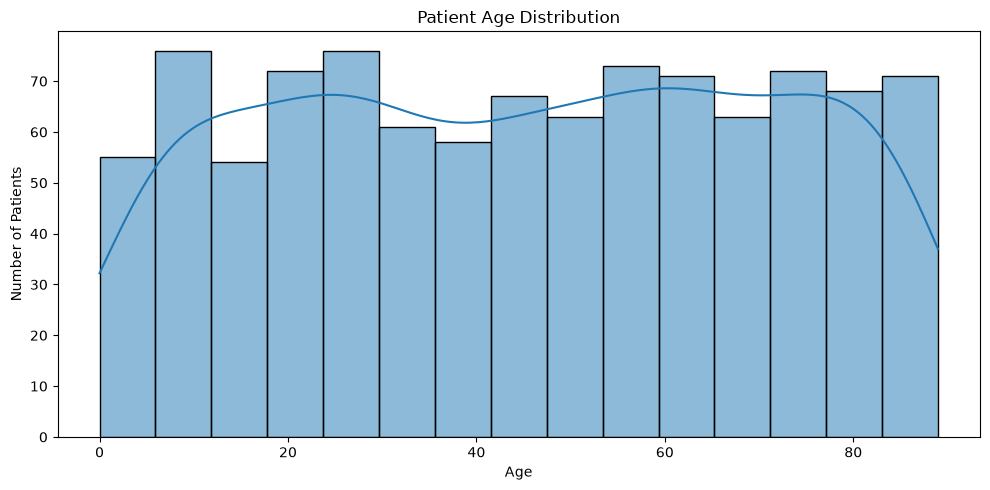

In [5]:
# AGE DISTRIBUTION

if "age" in patients.columns:

    print("\n" + "=" * 80)
    print("PATIENT AGE DISTRIBUTION")
    print("=" * 80)

    print(
        "Average Age:",
        round(patients["age"].mean(), 2)
    )

    print(
        "Median Age:",
        round(patients["age"].median(), 2)
    )

    plt.figure(figsize=(10, 5))

    sns.histplot(
        patients["age"].dropna(),
        bins=15,
        kde=True
    )

    plt.title("Patient Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Number of Patients")
    plt.tight_layout()
    plt.show()

## 5. Length of Stay Analysis

Compare stay-length statistics and view the distribution and outliers.


LENGTH OF STAY ANALYSIS
Average Length of Stay: 7.41 days
Median Length of Stay: 7.0 days
Minimum Length of Stay: 1.0 days
Maximum Length of Stay: 14.0 days


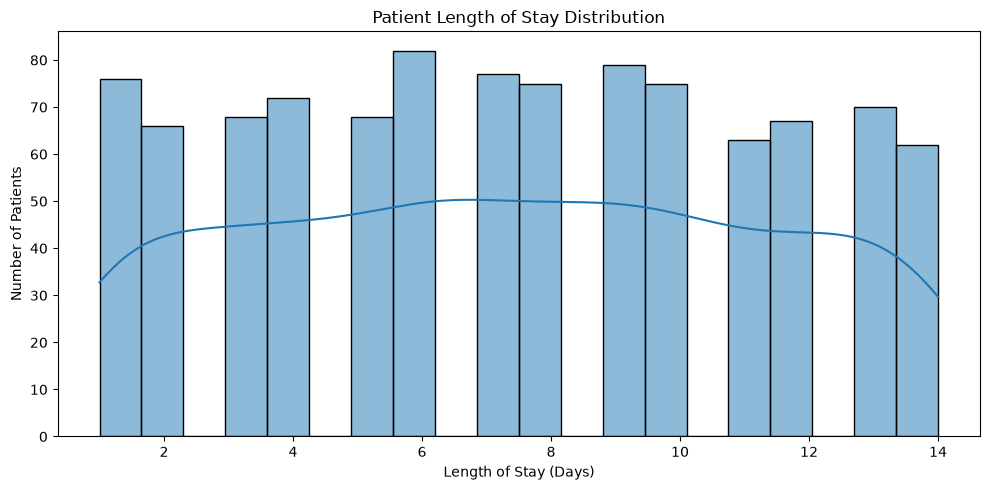

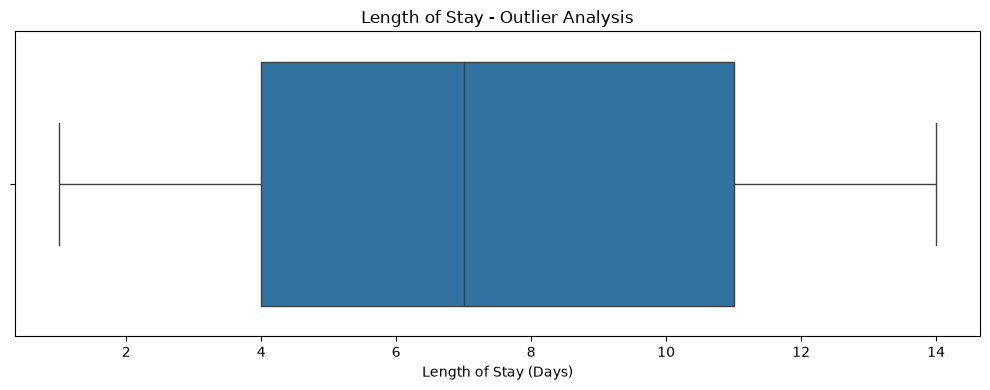

In [6]:
# LENGTH OF STAY ANALYSIS

if "length_of_stay" in patients.columns:

    print("\n" + "=" * 80)
    print("LENGTH OF STAY ANALYSIS")
    print("=" * 80)

    los = patients["length_of_stay"].dropna()

    print(
        "Average Length of Stay:",
        round(los.mean(), 2),
        "days"
    )

    print(
        "Median Length of Stay:",
        round(los.median(), 2),
        "days"
    )

    print(
        "Minimum Length of Stay:",
        round(los.min(), 2),
        "days"
    )

    print(
        "Maximum Length of Stay:",
        round(los.max(), 2),
        "days"
    )

    plt.figure(figsize=(10, 5))

    sns.histplot(
        los,
        bins=20,
        kde=True
    )

    plt.title("Patient Length of Stay Distribution")
    plt.xlabel("Length of Stay (Days)")
    plt.ylabel("Number of Patients")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=los
    )

    plt.title("Length of Stay - Outlier Analysis")
    plt.xlabel("Length of Stay (Days)")
    plt.tight_layout()
    plt.show()

## 6. Service and Department Analysis

Compare patient counts across services or departments.


PATIENTS BY SERVICE / DEPARTMENT


,Patient_Count
service,
emergency,263
surgery,254
general_medicine,242
ICU,241


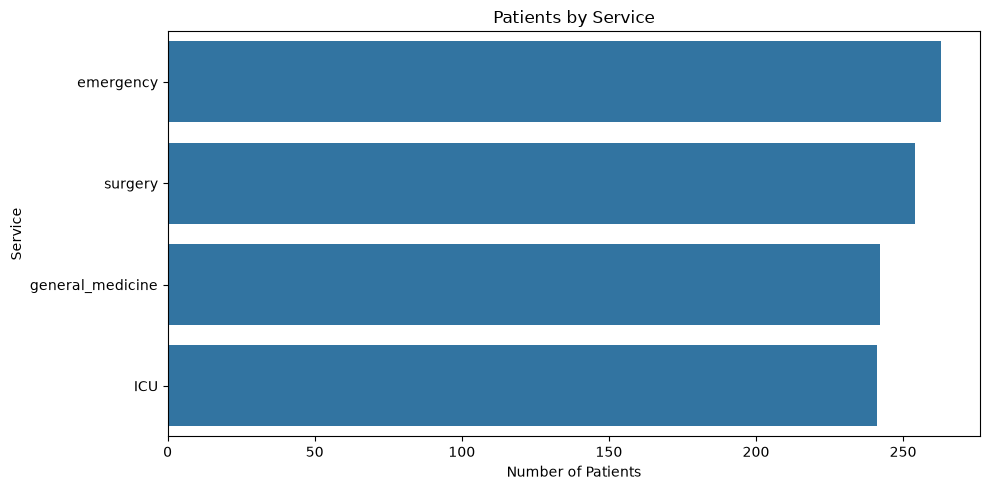

In [7]:
#  SERVICE / DEPARTMENT ANALYSIS

service_columns = [
    column
    for column in patients.columns
    if column in [
        "service",
        "department",
        "department_name",
        "hospital_service"
    ]
]

if len(service_columns) > 0:

    service_column = service_columns[0]

    print("\n" + "=" * 80)
    print("PATIENTS BY SERVICE / DEPARTMENT")
    print("=" * 80)

    service_counts = (
        patients[service_column]
        .value_counts()
        .sort_values(ascending=False)
    )

    display(
        service_counts.to_frame(
            name="Patient_Count"
        )
    )

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=service_counts.values,
        y=service_counts.index
    )

    plt.title(
        f"Patients by {service_column.replace('_', ' ').title()}"
    )
    plt.xlabel("Number of Patients")
    plt.ylabel(
        service_column.replace("_", " ").title()
    )
    plt.tight_layout()
    plt.show()

## 7. Patient Satisfaction

Summarize satisfaction scores and visualize their distribution.


PATIENT SATISFACTION ANALYSIS
Average Satisfaction: 79.6
Median Satisfaction: 80.0
Minimum Satisfaction: 60
Maximum Satisfaction: 99


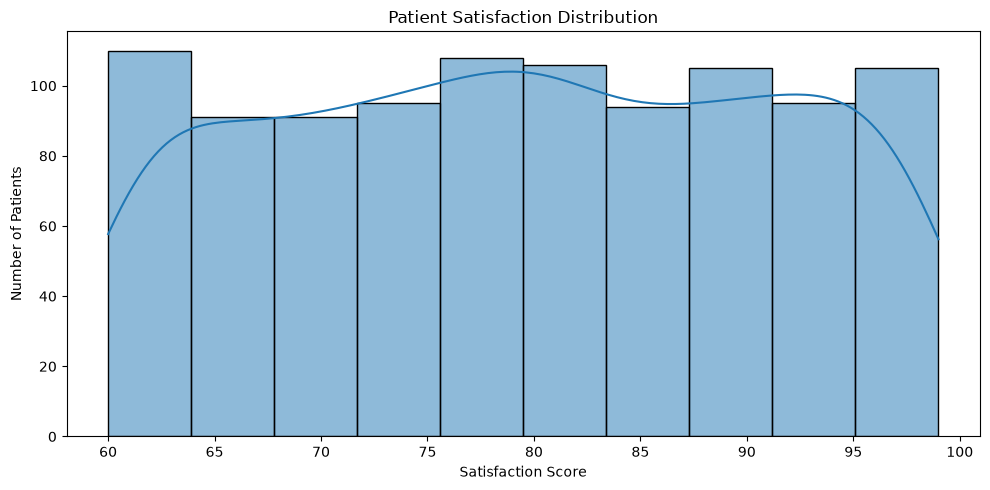

In [8]:
# PATIENT SATISFACTION ANALYSIS

if "satisfaction" in patients.columns:

    print("\n" + "=" * 80)
    print("PATIENT SATISFACTION ANALYSIS")
    print("=" * 80)

    satisfaction = patients["satisfaction"].dropna()

    print(
        "Average Satisfaction:",
        round(satisfaction.mean(), 2)
    )

    print(
        "Median Satisfaction:",
        round(satisfaction.median(), 2)
    )

    print(
        "Minimum Satisfaction:",
        satisfaction.min()
    )

    print(
        "Maximum Satisfaction:",
        satisfaction.max()
    )

    plt.figure(figsize=(10, 5))

    sns.histplot(
        satisfaction,
        bins=10,
        kde=True
    )

    plt.title("Patient Satisfaction Distribution")
    plt.xlabel("Satisfaction Score")
    plt.ylabel("Number of Patients")
    plt.tight_layout()
    plt.show()

## 8. Correlation Analysis

Inspect relationships among numeric patient fields.


CORRELATION ANALYSIS

Correlation Matrix:


,age,satisfaction,length_of_stay
age,1.00,-0.06,-0.05
satisfaction,-0.06,1.00,0.07
length_of_stay,-0.05,0.07,1.00


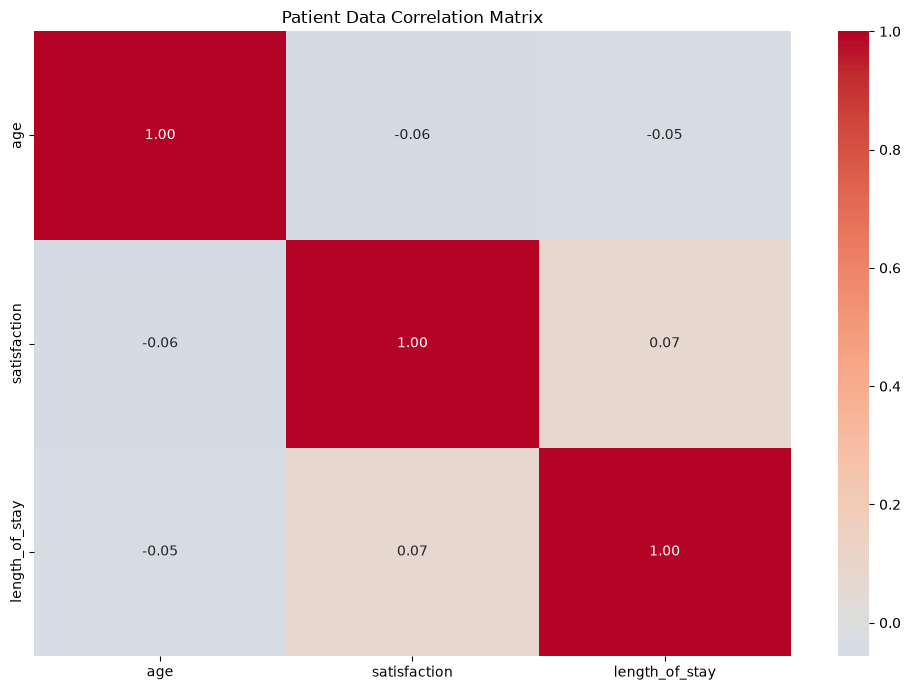

In [9]:
# NUMERICAL CORRELATION ANALYSIS

print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

numeric_patients = patients.select_dtypes(
    include=np.number
)

if numeric_patients.shape[1] >= 2:

    correlation = numeric_patients.corr()

    print("\nCorrelation Matrix:")
    display(
        correlation.round(2)
    )

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title("Patient Data Correlation Matrix")
    plt.tight_layout()
    plt.show()

## 9. Weekly Services Analysis

Review weekly service data and numeric totals and averages.

In [10]:
# SERVICES WEEKLY ANALYSIS

print("\n" + "=" * 80)
print("SERVICES WEEKLY ANALYSIS")
print("=" * 80)

print("\nServices Weekly Preview:")
display(services.head(10))

numeric_service_columns = services.select_dtypes(
    include=np.number
).columns.tolist()

if len(numeric_service_columns) > 0:

    print("\nNumerical columns in services_weekly:")

    for column in numeric_service_columns:

        print(
            f"{column}: "
            f"Total = {services[column].sum():,.2f}, "
            f"Average = {services[column].mean():,.2f}"
        )


SERVICES WEEKLY ANALYSIS

Services Weekly Preview:


,week,month,service,available_beds,patients_request,patients_admitted,patients_refused,patient_satisfaction,staff_morale,event
0,1,1,emergency,32,76,32,44,67,70,none
1,1,1,surgery,45,130,45,85,83,78,flu
2,1,1,general_medicine,37,201,37,164,97,43,flu
3,1,1,ICU,22,31,22,9,84,91,flu
4,2,1,emergency,28,169,28,141,75,64,none
5,2,1,surgery,40,26,26,0,96,56,none
6,2,1,general_medicine,43,183,43,140,73,93,flu
7,2,1,ICU,16,7,7,0,79,85,donation
8,3,1,emergency,32,177,32,145,73,58,flu
9,3,1,surgery,27,66,27,39,63,72,flu



Numerical columns in services_weekly:
week: Total = 5,512.00, Average = 26.50
month: Total = 1,440.00, Average = 6.92
available_beds: Total = 6,312.00, Average = 30.35
patients_request: Total = 13,493.00, Average = 64.87
patients_admitted: Total = 5,851.00, Average = 28.13
patients_refused: Total = 7,642.00, Average = 36.74
patient_satisfaction: Total = 16,640.00, Average = 80.00
staff_morale: Total = 15,094.00, Average = 72.57


## 10. Staff and Schedule Analysis

Inspect staff categories and staffing schedule summaries.

In [11]:
# STAFF ANALYSIS

print("\n" + "=" * 80)
print("STAFF ANALYSIS")
print("=" * 80)

print("\nStaff Preview:")
display(staff.head(10))

staff_categorical = staff.select_dtypes(
    include=["object", "string"]
).columns

for column in staff_categorical:

    unique_count = staff[column].nunique()

    if unique_count <= 20:

        print(
            f"\nStaff distribution by {column}:"
        )

        counts = staff[column].value_counts()

        display(
            counts.to_frame(
                name="Staff_Count"
            )
        )

# STAFF SCHEDULE ANALYSIS

print("\n" + "=" * 80)
print("STAFF SCHEDULE ANALYSIS")
print("=" * 80)

print("\nStaff Schedule Preview:")
display(staff_schedule.head(10))

schedule_numeric = staff_schedule.select_dtypes(
    include=np.number
).columns

if len(schedule_numeric) > 0:

    print("\nSchedule numerical summary:")

    display(
        staff_schedule[schedule_numeric]
        .describe()
        .T
        .round(2)
    )


STAFF ANALYSIS

Staff Preview:


,staff_id,staff_name,role,service
0,STF-5ca26577,Allison Hill,doctor,emergency
1,STF-02ae59ca,Noah Rhodes,doctor,emergency
2,STF-d8006e7c,Angie Henderson,doctor,emergency
3,STF-212d8b31,Daniel Wagner,doctor,emergency
4,STF-107a58e4,Cristian Santos,doctor,emergency
5,STF-ca932dea,Connie Lawrence,nurse,emergency
6,STF-39082289,Abigail Shaffer,nurse,emergency
7,STF-702887af,Gina Moore,nurse,emergency
8,STF-249f63bb,Gabrielle Davis,nurse,emergency
9,STF-094f410b,Ryan Munoz,nurse,emergency



Staff distribution by role:


,Staff_Count
role,
nurse,69
nursing_assistant,23
doctor,18



Staff distribution by service:


,Staff_Count
service,
ICU,32
emergency,29
general_medicine,27
surgery,22



STAFF SCHEDULE ANALYSIS

Staff Schedule Preview:


,week,staff_id,staff_name,role,service,present
0,1,STF-b77cdc60,Allison Hill,doctor,emergency,1
1,2,STF-b77cdc60,Allison Hill,doctor,emergency,1
2,3,STF-b77cdc60,Allison Hill,doctor,emergency,0
3,4,STF-b77cdc60,Allison Hill,doctor,emergency,1
4,5,STF-b77cdc60,Allison Hill,doctor,emergency,1
5,6,STF-b77cdc60,Allison Hill,doctor,emergency,0
6,7,STF-b77cdc60,Allison Hill,doctor,emergency,1
7,8,STF-b77cdc60,Allison Hill,doctor,emergency,1
8,9,STF-b77cdc60,Allison Hill,doctor,emergency,0
9,10,STF-b77cdc60,Allison Hill,doctor,emergency,1



Schedule numerical summary:


,count,mean,std,min,25%,50%,75%,max
week,6552.0,26.5,15.01,1.0,13.75,26.5,39.25,52.0
present,6552.0,0.6,0.49,0.0,0.00,1.0,1.00,1.0


## 11. Outliers and Hospital KPIs

Flag numeric outliers and review initial hospital metrics.

In [12]:
# AUTOMATIC OUTLIER DETECTION

print("\n" + "=" * 80)
print("OUTLIER DETECTION")
print("=" * 80)

for column in patients.select_dtypes(
    include=np.number
).columns:

    series = patients[column].dropna()

    if len(series) > 0:

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = series[
            (series < lower_bound)
            |
            (series > upper_bound)
        ]

        print(
            f"{column:<25} : "
            f"{len(outliers):,} outliers"
        )

# IMPORTANT KPI PREVIEW

print("\n" + "=" * 80)
print("INITIAL HOSPITAL KPI PREVIEW")
print("=" * 80)

print(
    "\nTotal Patients:",
    f"{len(patients):,}"
)

if "age" in patients.columns:
    print(
        "Average Patient Age:",
        round(patients["age"].mean(), 2)
    )

if "length_of_stay" in patients.columns:
    print(
        "Average Length of Stay:",
        round(
            patients["length_of_stay"].mean(),
            2
        ),
        "days"
    )

if "satisfaction" in patients.columns:
    print(
        "Average Satisfaction:",
        round(
            patients["satisfaction"].mean(),
            2
        )
    )

print(
    "Total Staff:",
    f"{len(staff):,}"
)


OUTLIER DETECTION
age                       : 0 outliers
satisfaction              : 0 outliers
length_of_stay            : 0 outliers

INITIAL HOSPITAL KPI PREVIEW

Total Patients: 1,000
Average Patient Age: 45.34
Average Length of Stay: 7.41 days
Average Satisfaction: 79.6
Total Staff: 110


## 12. Save EDA Summary

Export the key analysis metrics to the processed-data folder.

In [13]:
# SAVE EDA SUMMARY

eda_summary = {
    "Metric": [
        "Total Patients",
        "Total Staff"
    ],
    "Value": [
        len(patients),
        len(staff)
    ]
}

if "age" in patients.columns:
    eda_summary["Metric"].append(
        "Average Patient Age"
    )
    eda_summary["Value"].append(
        round(patients["age"].mean(), 2)
    )

if "length_of_stay" in patients.columns:
    eda_summary["Metric"].append(
        "Average Length of Stay"
    )
    eda_summary["Value"].append(
        round(
            patients["length_of_stay"].mean(),
            2
        )
    )

if "satisfaction" in patients.columns:
    eda_summary["Metric"].append(
        "Average Satisfaction"
    )
    eda_summary["Value"].append(
        round(
            patients["satisfaction"].mean(),
            2
        )
    )

eda_summary_df = pd.DataFrame(eda_summary)

eda_summary_df.to_csv(
    PROCESSED_PATH / "eda_summary.csv",
    index=False
)

## 13. Completion

Confirm the EDA workflow has finished and note the next analysis step.

In [14]:
# FINAL MESSAGE

print("\n" + "=" * 80)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\nGenerated analysis:")
print("✓ Dataset overview")
print("✓ Missing-value analysis")
print("✓ Numerical statistics")
print("✓ Categorical analysis")
print("✓ Age distribution")
print("✓ Length-of-stay analysis")
print("✓ Service/department analysis")
print("✓ Satisfaction analysis")
print("✓ Correlation analysis")
print("✓ Staff analysis")
print("✓ Staff schedule analysis")
print("✓ Outlier detection")
print("✓ Initial hospital KPIs")

print("\nEDA summary saved to:")
print(PROCESSED_PATH / "eda_summary.csv")

print("\nNext step:")
print("→ Open 04_kpi_analysis.ipynb")
print("→ Calculate final hospital KPIs")
print("→ Prepare data for MySQL and Power BI")


EDA COMPLETED SUCCESSFULLY

Generated analysis:
✓ Dataset overview
✓ Missing-value analysis
✓ Numerical statistics
✓ Categorical analysis
✓ Age distribution
✓ Length-of-stay analysis
✓ Service/department analysis
✓ Satisfaction analysis
✓ Correlation analysis
✓ Staff analysis
✓ Staff schedule analysis
✓ Outlier detection
✓ Initial hospital KPIs

EDA summary saved to:
c:\Users\khala\Project\Hospital-Patient-Analytics\data\processed\eda_summary.csv

Next step:
→ Open 04_kpi_analysis.ipynb
→ Calculate final hospital KPIs
→ Prepare data for MySQL and Power BI
